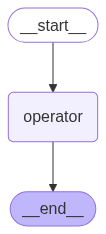

In [21]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    numb : List[int]
    name : str
    operation : str
    result : str

def operations(state: AgentState) -> AgentState:
    """Does addition or multiplication"""
    if state["operation"] == "+":
        state["result"] = f"Hi {state['name']} is {sum(state['numb'])}!"
    elif state["operation"] == "*":
        state["result"] = f"Hi {state['name']}! Your result is {sum(state['numb'])} wrong"
    else:
        state["result"] = f"Hi {state['name']}! Operator invalid"

graph = StateGraph(AgentState)

graph.add_node("operator", operations)
graph.set_entry_point("operator")
graph.set_finish_point("operator")

app = graph.compile()
app


In [23]:
answers = app.invoke({"values": [1, 2, 3, 4], "name": "Steve"})

print(answers["result"])

print()
answers

KeyError: 'operation'